#### binary classification

In [2]:
from tensorflow.keras.datasets import imdb


I0000 00:00:1774463737.968470    5636 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774463739.199437    5636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774463743.628206    5636 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

/home/nuno/miniconda3/envs/deeplearning/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


You’ll work with the IMDB dataset: a set of 50,000 highly polarized reviews from the
Internet Movie Database. They’re split into 25,000 reviews for training and 25,000
reviews for testing, each set consisting of 50% negative and 50% positive reviews.

 IT has already been preprocessed: the reviews (sequences of words) have been turned into
sequences of integers, where each integer stands for a specific word in a dictionary.

s with the IMDB dataset, the argument num_words=10000 restricts the data to the
10,000 most frequently occurring words found in the data

In [4]:
train_data.shape

(25000,)

In [5]:
len(train_data)

25000

In [6]:
# each of observation is a list containing the words of the 10000 most common words in the reviews.
# each word is encode as a number
# so the max size of each observation is 9999 index


In [7]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])

In [8]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [10]:
import numpy as np

In [11]:
# 1. encoding

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [12]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [13]:
# test and val sets 
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [14]:
partial_x_train.shape

(15000, 10000)

In [15]:
x_val.shape

(10000, 10000)

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

In [24]:
# baseline
model = keras.Sequential([layers.Dense(16, activation="relu"),
                          layers.Dense(16, activation="relu"),
                          layers.Dense(1, activation="sigmoid")])

In [29]:
#  binary classification problem 
#  output of your model is a probability (single-unit layer with a sigmoid activation)


# LOSS_function
# binary_crossentropy loss 
# Crossentropy is a quantity that measures the distance between probability distributions or, in this
# case, between the ground-truth distribution and your predictions.

# optimizer
# As for the choice of the optimizer, we’ll go with rmsprop, which is a usually a good
# default choice for virtually any problem.

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

E0000 00:00:1774462217.240573   23221 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Binary cross-entropy loss

For one observation:

$$
L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]
$$

For \(N\) observations:

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

### Parameters

- \(L\): binary cross-entropy loss
- \(N\): number of observations
- \(y\): true label for one observation, usually 0 or 1
- \(\hat{y}\): predicted probability of class 1, between 0 and 1
- \(y_i\): true label of observation \(i\)
- \(\hat{y}_i\): predicted probability for observation \(i\)
- \(\log\): natural logarithm
- \(i\): observation index, from 1 to \(N\)

### Special cases

If \(y = 1\):

$$
L = -\log(\hat{y})
$$

If \(y = 0\):

$$
L = -\log(1-\hat{y})
$$

In [ ]:
# partial_x_train has 15000 obs
# each of the 20 epochs will be composed by 30 training loops with 512 obs each

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

W0000 00:00:1774462506.442147   23221 cpu_allocator_impl.cc:82] Allocation of 600000000 exceeds 10% of free system memory.


Epoch 1/20
 1/30 ━━━━━━━━━━━━━━━━━━━━ 1:28 3s/step - accuracy: 0.4785 - loss: 0.6960

W0000 00:00:1774462511.858068   26472 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1774462511.858102   26467 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1774462511.858155   26468 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1774462511.858023   26473 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.


30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 466ms/step - accuracy: 0.7755 - loss: 0.5219 - val_accuracy: 0.8687 - val_loss: 0.3909
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8966 - loss: 0.3191 - val_accuracy: 0.8849 - val_loss: 0.3082
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9210 - loss: 0.2372 - val_accuracy: 0.8847 - val_loss: 0.2915
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9375 - loss: 0.1898 - val_accuracy: 0.8883 - val_loss: 0.2737
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9470 - loss: 0.1609 - val_accuracy: 0.8831 - val_loss: 0.2966
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9587 - loss: 0.1334 - val_accuracy: 0.8839 - val_loss: 0.2974
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9655 - loss: 0.1150 - val_accuracy: 0.8841 - val_loss: 0.3041
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9740 - loss: 0.0948 - val_accuracy: 0.8838 - val_loss: 

In [36]:
history_dict = history.history

In [37]:
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [25]:
import matplotlib.pyplot as plt

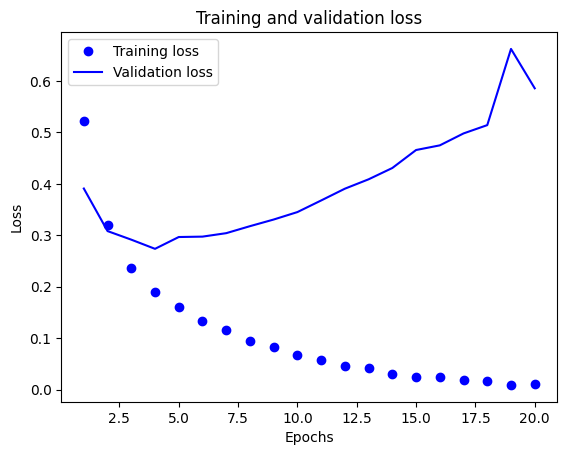

In [39]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

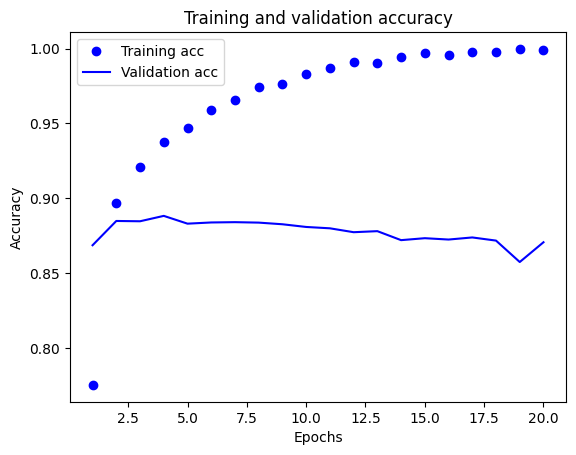

In [43]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [40]:
len(loss_values)

20

In [42]:
len(history_dict["accuracy"])

20

In [17]:
# we must define the model again, else it would start with the optimized weights of the previous
model = keras.Sequential([
layers.Dense(16, activation="relu"),
layers.Dense(16, activation="relu"),
layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
loss="binary_crossentropy",
metrics=["accuracy"])



E0000 00:00:1774463867.045679    5636 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

W0000 00:00:1774463876.117400    5636 cpu_allocator_impl.cc:82] Allocation of 1000000000 exceeds 10% of free system memory.


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8134 - loss: 0.4510
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9048 - loss: 0.2646
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9251 - loss: 0.2091
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9362 - loss: 0.1789


W0000 00:00:1774463898.684146    5636 cpu_allocator_impl.cc:82] Allocation of 1000000000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8833 - loss: 0.2934


In [19]:
results

[0.2934421896934509, 0.8833199739456177]

In [20]:
model.predict(x_test)

W0000 00:00:1774464380.581552    5636 cpu_allocator_impl.cc:82] Allocation of 1000000000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.2270357 ],
       [0.9997941 ],
       [0.9492986 ],
       ...,
       [0.13306177],
       [0.09217104],
       [0.8183475 ]], shape=(25000, 1), dtype=float32)

In [22]:
model = keras.Sequential([
layers.Dense(16, activation="relu"),
layers.Dense(16, activation="relu"),
layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
loss="mse",
metrics=["accuracy"])


In [23]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


W0000 00:00:1774465274.661123    5636 cpu_allocator_impl.cc:82] Allocation of 600000000 exceeds 10% of free system memory.


27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6803 - loss: 0.2192

W0000 00:00:1774465289.813756    5636 cpu_allocator_impl.cc:82] Allocation of 400000000 exceeds 10% of free system memory.


30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 451ms/step - accuracy: 0.7702 - loss: 0.1874 - val_accuracy: 0.8371 - val_loss: 0.1410
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8829 - loss: 0.1110 - val_accuracy: 0.8603 - val_loss: 0.1108
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9115 - loss: 0.0818 - val_accuracy: 0.8830 - val_loss: 0.0931
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9265 - loss: 0.0666 - val_accuracy: 0.8755 - val_loss: 0.0936
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9379 - loss: 0.0569 - val_accuracy: 0.8891 - val_loss: 0.0845
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9470 - loss: 0.0497 - val_accuracy: 0.8789 - val_loss: 0.0879
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9535 - loss: 0.0443 - val_accuracy: 0.8862 - val_loss: 0.0863
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9586 - loss: 0.0393 - val_accuracy: 0.8849 - val_loss: 

W0000 00:00:1774465299.734807    7866 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 20482048 bytes after encountering the first element of size 20482048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9693 - loss: 0.0315 - val_accuracy: 0.8818 - val_loss: 0.0908
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9735 - loss: 0.0283 - val_accuracy: 0.8737 - val_loss: 0.0920
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9769 - loss: 0.0253 - val_accuracy: 0.8635 - val_loss: 0.1007
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9803 - loss: 0.0236 - val_accuracy: 0.8791 - val_loss: 0.0894
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9821 - loss: 0.0210 - val_accuracy: 0.8755 - val_loss: 0.0920
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9851 - loss: 0.0183 - val_accuracy: 0.8695 - val_loss: 0.1022
Epoch 16/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9851 - loss: 0.0174 - val_accuracy: 0.8766 - val_loss: 0.0932
Epoch 17/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9870 - loss: 0.0158 - val_accuracy: 0.8748 - val_l

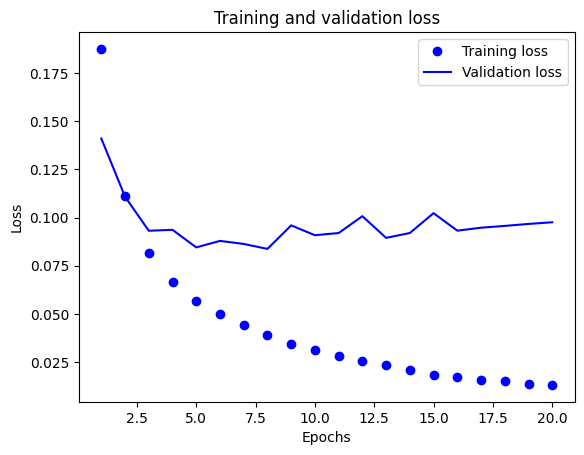

In [26]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

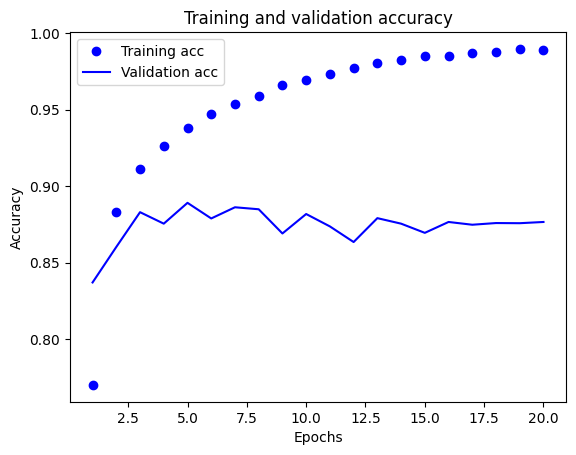

In [27]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()